# PA5
Group 9: Melker Gustafsson, Ismail Sacic, Pontus Gideflod

## Example data

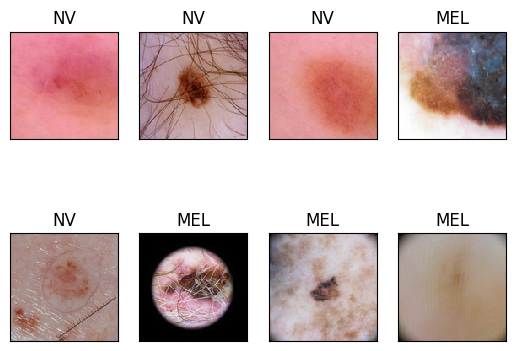

In [13]:
import torchvision
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

folder = ImageFolder('data\\a5_data_new\\train', transform=torchvision.transforms.ToTensor())
loader = DataLoader(folder, batch_size=8, shuffle=True)

Xexamples, Yexamples = next(iter(loader))

for i in range(8):
    plt.subplot(2,4,i+1)  
    img = Xexamples[i].numpy().transpose(1, 2, 0)    
    plt.imshow(img, interpolation='none')
    plt.title('NV' if Yexamples[i] else 'MEL')
    plt.xticks([])
    plt.yticks([])

## Task 1:

Set up a machine learning architecture for an image classifier and train it on the training set. Explore and compare different solutions and evaluate them on the validation set. You can use accuracy score as the performance metric to compare the different solutions.

In [14]:
import torch
import torch.nn as nn

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
all_results = {}

loss_fn = nn.CrossEntropyLoss()

def train_eval(model, name, train_ldr, val_ldr, epochs=10, lr=0.001):
    if name in all_results:
        print(f"SKIP '{name}' (best_acc={all_results[name]['best_acc']:.4f})")
        return
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    best_acc, accs = 0.0, []

    for epoch in range(epochs):
        model.train()
        for X, y in train_ldr:
            X, y = X.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); loss_fn(model(X), y).backward(); opt.step()
        model.eval()
        correct = 0
        with torch.no_grad():
            for X, y in val_ldr:
                correct += (model(X.to(DEVICE)).argmax(1).cpu() == y).sum().item()
        acc = correct / len(val_ldr.dataset)
        best_acc = max(best_acc, acc)
        accs.append(acc)
        print(f'  {name} Epoch {epoch+1}/{epochs}  val_acc={acc:.4f}')

    all_results[name] = {'best_acc': best_acc, 'epochs': accs}
    print(f'  Best: {best_acc:.4f}.\n')

Above you can see the function that we will use to run our different models and evaluate their resulting accuracies.

In [15]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader


DATA = 'data/a5_data_new'
print('Using device:', DEVICE)

tf = transforms.Compose([transforms.Resize((128, 128)), transforms.ToTensor()])
train_loader     = DataLoader(ImageFolder(f'{DATA}/train', tf),     batch_size=32, shuffle=True)
val_loader       = DataLoader(ImageFolder(f'{DATA}/val', tf),       batch_size=32)

baseline = nn.Sequential(
        nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Flatten(), nn.Linear(128*16*16, 2), 
    )

train_eval(baseline, 'baseline', train_loader, val_loader, epochs=10, lr=0.001)


Using device: cuda
  baseline Epoch 1/10  val_acc=0.7859
  baseline Epoch 2/10  val_acc=0.7955
  baseline Epoch 3/10  val_acc=0.7859
  baseline Epoch 4/10  val_acc=0.8035
  baseline Epoch 5/10  val_acc=0.7875
  baseline Epoch 6/10  val_acc=0.7923
  baseline Epoch 7/10  val_acc=0.8243
  baseline Epoch 8/10  val_acc=0.8131
  baseline Epoch 9/10  val_acc=0.8091
  baseline Epoch 10/10  val_acc=0.8299
  Best: 0.8299.



Above you can see the model we used as our baseline. It is a basic Neural Network model with 3 layers.

In [16]:
model_norms = {
    'batch_norm': nn.Sequential(
        nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        nn.Flatten(), nn.Linear(128*16*16, 2),
    ),
    'layer_norm': nn.Sequential(
        nn.Conv2d(3,32,3,padding=1), nn.LayerNorm([32,128,128]), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32,64,3,padding=1), nn.LayerNorm([64,64,64]), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(64,128,3,padding=1), nn.LayerNorm([128,32,32]), nn.ReLU(), nn.MaxPool2d(2),
        nn.Flatten(), nn.Linear(128*16*16, 2),
    ),
    'group_norm': nn.Sequential(
        nn.Conv2d(3,32,3,padding=1), nn.GroupNorm(4, 32), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32,64,3,padding=1), nn.GroupNorm(8, 64), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(64,128,3,padding=1), nn.GroupNorm(16, 128), nn.ReLU(), nn.MaxPool2d(2),
        nn.Flatten(), nn.Linear(128*16*16, 2),
    )
}


for name, model in model_norms.items():
        train_eval(model, name, train_loader, val_loader, epochs=10)

  batch_norm Epoch 1/10  val_acc=0.7772
  batch_norm Epoch 2/10  val_acc=0.7939
  batch_norm Epoch 3/10  val_acc=0.7588
  batch_norm Epoch 4/10  val_acc=0.7843
  batch_norm Epoch 5/10  val_acc=0.7851
  batch_norm Epoch 6/10  val_acc=0.7636
  batch_norm Epoch 7/10  val_acc=0.6637
  batch_norm Epoch 8/10  val_acc=0.7931
  batch_norm Epoch 9/10  val_acc=0.7812
  batch_norm Epoch 10/10  val_acc=0.8099
  Best: 0.8099.

  layer_norm Epoch 1/10  val_acc=0.5815
  layer_norm Epoch 2/10  val_acc=0.7692
  layer_norm Epoch 3/10  val_acc=0.7987
  layer_norm Epoch 4/10  val_acc=0.7915
  layer_norm Epoch 5/10  val_acc=0.7396
  layer_norm Epoch 6/10  val_acc=0.7963
  layer_norm Epoch 7/10  val_acc=0.7061
  layer_norm Epoch 8/10  val_acc=0.8331
  layer_norm Epoch 9/10  val_acc=0.8219
  layer_norm Epoch 10/10  val_acc=0.8291
  Best: 0.8331.

  group_norm Epoch 1/10  val_acc=0.7955
  group_norm Epoch 2/10  val_acc=0.7460
  group_norm Epoch 3/10  val_acc=0.6573
  group_norm Epoch 4/10  val_acc=0.7923
  gr

Then we tried different forms of normalizations and came to the conclusion that batch normalization had the best results.

In [17]:
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1), nn.BatchNorm2d(ch), nn.ReLU(),
            nn.Conv2d(ch, ch, 3, padding=1), nn.BatchNorm2d(ch),
        )
    def forward(self, x):
        return nn.functional.relu(self.block(x) + x)
    
residual = nn.Sequential(
        nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
        ResBlock(32),
        nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        ResBlock(64),
        nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        ResBlock(128),
        nn.Flatten(), nn.Linear(128*16*16, 2),
    )

train_eval(residual, 'residual', train_loader, val_loader, epochs=10)

  residual Epoch 1/10  val_acc=0.6829
  residual Epoch 2/10  val_acc=0.7668
  residual Epoch 3/10  val_acc=0.7772
  residual Epoch 4/10  val_acc=0.7300
  residual Epoch 5/10  val_acc=0.7372
  residual Epoch 6/10  val_acc=0.8043
  residual Epoch 7/10  val_acc=0.7931
  residual Epoch 8/10  val_acc=0.8075
  residual Epoch 9/10  val_acc=0.7843
  residual Epoch 10/10  val_acc=0.8235
  Best: 0.8235.



Then we tried residual connections on top of the batch normalization as well, however this seemed to have negative effects on performance.

In [18]:
tf_aug = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20), transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor(),
])

train_loader_aug = DataLoader(ImageFolder(f'{DATA}/train', tf_aug), batch_size=32, shuffle=True)

augmented = nn.Sequential(
        nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
        ResBlock(32),
        nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        ResBlock(64),
        nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        ResBlock(128),
        nn.Flatten(), nn.Linear(128*16*16, 2),
    )

train_eval(augmented, 'residual_augmented', train_loader_aug, val_loader, epochs=10)

  residual_augmented Epoch 1/10  val_acc=0.7508
  residual_augmented Epoch 2/10  val_acc=0.7196
  residual_augmented Epoch 3/10  val_acc=0.7612
  residual_augmented Epoch 4/10  val_acc=0.7388
  residual_augmented Epoch 5/10  val_acc=0.7548
  residual_augmented Epoch 6/10  val_acc=0.7652
  residual_augmented Epoch 7/10  val_acc=0.7428
  residual_augmented Epoch 8/10  val_acc=0.6310
  residual_augmented Epoch 9/10  val_acc=0.7692
  residual_augmented Epoch 10/10  val_acc=0.8003
  Best: 0.8003.



Next, we tried applying random transformations to the images which had ... results.

In [19]:
import os, numpy as np
import torchvision
from torch.utils.data import TensorDataset

if 'transfer_vgg16' in all_results:
        print(f"SKIP 'transfer_vgg16' (best_acc={all_results['transfer_vgg16']['best_acc']:.4f})")
else:
    feat_file = 'vgg_features.npz'
    if os.path.exists(feat_file):
        print("Loading cached VGG features...")
        d = np.load(feat_file)
        X_tr, y_tr, X_va, y_va = [torch.tensor(d[k]) for k in ['X_tr','y_tr','X_va','y_va']]
    else:
        print("Extracting VGG features (one time only)...")
        w = torchvision.models.VGG16_Weights.IMAGENET1K_V1
        vgg = torchvision.models.vgg16(weights=w).to(DEVICE).eval()
        def extract(path):
            feats, labels = [], []
            for X, y in DataLoader(ImageFolder(path, w.transforms()), batch_size=32):
                with torch.no_grad():
                    f = vgg.avgpool(vgg.features(X.to(DEVICE))).flatten(1).cpu()
                feats.append(f); labels.append(y)
            return torch.cat(feats), torch.cat(labels)
        X_tr, y_tr = extract(f'{DATA}/train')
        X_va, y_va = extract(f'{DATA}/val')
        np.savez(feat_file, X_tr=X_tr.numpy(), y_tr=y_tr.numpy(), X_va=X_va.numpy(), y_va=y_va.numpy())
    clf = nn.Sequential(
        nn.Linear(X_tr.shape[1], 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(256, 2),
    )
    train_eval(clf, 'transfer_vgg16',
               DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True),
               DataLoader(TensorDataset(X_va, y_va), batch_size=64), epochs=30)
    
print("\n" + "="*50 + "\nFINAL RESULTS\n" + "="*50)
for name, res in all_results.items():
    print(f"  {name:20s} best_acc={res['best_acc']:.4f}")

Loading cached VGG features...
  transfer_vgg16 Epoch 1/30  val_acc=0.8427
  transfer_vgg16 Epoch 2/30  val_acc=0.8634
  transfer_vgg16 Epoch 3/30  val_acc=0.8626
  transfer_vgg16 Epoch 4/30  val_acc=0.8746
  transfer_vgg16 Epoch 5/30  val_acc=0.8690
  transfer_vgg16 Epoch 6/30  val_acc=0.8634
  transfer_vgg16 Epoch 7/30  val_acc=0.8610
  transfer_vgg16 Epoch 8/30  val_acc=0.8658
  transfer_vgg16 Epoch 9/30  val_acc=0.8674
  transfer_vgg16 Epoch 10/30  val_acc=0.8690
  transfer_vgg16 Epoch 11/30  val_acc=0.8650
  transfer_vgg16 Epoch 12/30  val_acc=0.8698
  transfer_vgg16 Epoch 13/30  val_acc=0.8658
  transfer_vgg16 Epoch 14/30  val_acc=0.8650
  transfer_vgg16 Epoch 15/30  val_acc=0.8634
  transfer_vgg16 Epoch 16/30  val_acc=0.8722
  transfer_vgg16 Epoch 17/30  val_acc=0.8642
  transfer_vgg16 Epoch 18/30  val_acc=0.8722
  transfer_vgg16 Epoch 19/30  val_acc=0.8706
  transfer_vgg16 Epoch 20/30  val_acc=0.8650
  transfer_vgg16 Epoch 21/30  val_acc=0.8690
  transfer_vgg16 Epoch 22/30  val

Lastly we tried to transfer learning using a pre-trained model and used it on our dataset. This was by far the best resulting model.

## Task 2

Compute the score on the test set with the labels and include it in the report.

In [21]:
test_path = f'data/a5_data_test/test'
if not os.path.exists(test_path):
    print(f"ERROR: test set not found at {test_path}")
    print("Download and extract the test set first.")
else:
    print("Extracting VGG features for test set...")
    feats, labels = [], []
    for X, y in DataLoader(ImageFolder(test_path, w.transforms()), batch_size=32):
        with torch.no_grad():
            f = vgg.avgpool(vgg.features(X.to(DEVICE))).flatten(1).cpu()
        feats.append(f); labels.append(y)
    X_test, y_test = torch.cat(feats), torch.cat(labels)
    print(f"Test set: {len(y_test)} images")

    # Load training features to get input size
    d = np.load(feat_file)
    X_tr, y_tr = torch.tensor(d['X_tr']), torch.tensor(d['y_tr'])

    # Rebuild the same classifier
    clf = nn.Sequential(
        nn.Linear(X_tr.shape[1], 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(256, 2),
    ).to(DEVICE)

    # Retrain on full training data (same as task 1)
    print("Training classifier on VGG features...")
    opt = torch.optim.Adam(clf.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()
    train_ldr = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)

    for epoch in range(30):
        clf.train()
        for X, y in train_ldr:
            X, y = X.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); loss_fn(clf(X), y).backward(); opt.step()

    # Evaluate on test set
    clf.eval()
    with torch.no_grad():
        preds = clf(X_test.to(DEVICE)).argmax(1).cpu()
    acc = (preds == y_test).float().mean().item()
    print(f"\n{'='*40}")
    print(f"TEST SET ACCURACY: {acc:.4f}")
    print(f"{'='*40}")

Extracting VGG features for test set...
Test set: 1366 images
Training classifier on VGG features...

TEST SET ACCURACY: 0.8565


Here we test our best performing model (transfered pre-trained) against the test set to get a result of ...